In [1]:
import numpy as np
import scipy.stats
from matplotlib import pyplot as plt

Method 1: given a set of data extracted from h(x), they are used to infer f(x), which is then upsampled using the hit-or-miss method

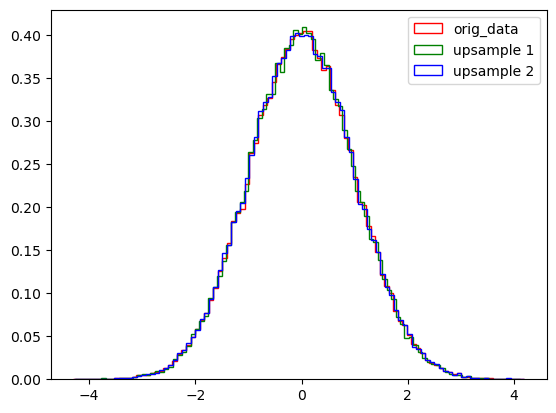

In [51]:
N = 100000
n1 = 100000
n2 = 1000000
#parameters of the distribution
mu = 0.
sigma = 1.

#sampling the distribution
gauss = scipy.stats.norm(mu, sigma)
data = [gauss.rvs(N)]

freq, bins = np.histogram(data, bins=100, density=True)
f = scipy.stats.rv_histogram((freq, bins)) #approximating h(x) with the normalized histo of the draws f(x)
upsample_1 = [f.rvs() for i in range(n1)] #extracting (upsampling) from f(x)

#manual implementation of the hit-or-miss method
ymax = freq.max()
x_unif = scipy.stats.uniform(bins[0], bins[-1]-bins[0])
y_unif = scipy.stats.uniform(0., ymax)
x = x_unif.rvs(n2)
y = y_unif.rvs(n2)
accept_condition = y<=f.pdf(x)
upsample_2 = x[accept_condition]

#plotting the three histrograms
plt.hist(data, 100, density=True, histtype='step', color='red', label='orig_data')
plt.hist(upsample_1, 100, density=True, histtype='step', color='green', label='upsample 1')
plt.hist(upsample_2, 100, density=True, histtype='step', color='blue', label='upsample 2')
plt.legend()
plt.show()

